# DTLZ2 Results

In [1]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 5
NPOP = 1000
NGEN = 300
NOBJ = 5 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz2_segura = partial(benchmarks.dtlz2, obj=NOBJ)
toolbox = build_toolbox(func_dtlz2_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 20
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


[1.0, 0.0, 0.0, 1.0665035235614809e-05, 0.4813179405801905, 0.4905026163012444, 0.49993482862322197, 0.4895347538228961, 0.4875671195689498]
[0.0, 0.0, 0.0, 7.961320980161234e-13, 0.49932643619720624, 0.5003640463430944, 0.519909206828111, 0.49984991432636433, 0.4996376836473796]
[1.0, 1.0, 1.0, 1.0, 0.49999940041920893, 0.499997871178072, 0.5000013652265359, 0.5000058256394202, 0.49999671219308595]
[0.00012265109147016184, 1.0, 0.0, 0.4261076144621169, 0.18972112713138886, 0.5560657278953518, 0.792645132728603, 0.4832206981600335, 0.76219467301218]
[1.0, 1.0, 0.0, 5.430047042173217e-17, 0.4999980836442969, 0.4999978158384115, 0.49999774175654127, 0.5000078675840877, 0.4999859323458504]
[0.0018183760962035, 0.0, 9.59319494157503e-18, 3.6121543623856607e-17, 0.6805842320324456, 0.5010566732132264, 0.5000024440700317, 0.5000565415222411, 0.4999457946150181]
[1.0, 1.0, 0.008328496569295185, 1.0, 0.30712536400545, 0.5251858763355387, 0.500107796320524, 0.5000059682351466, 0.503654707085207

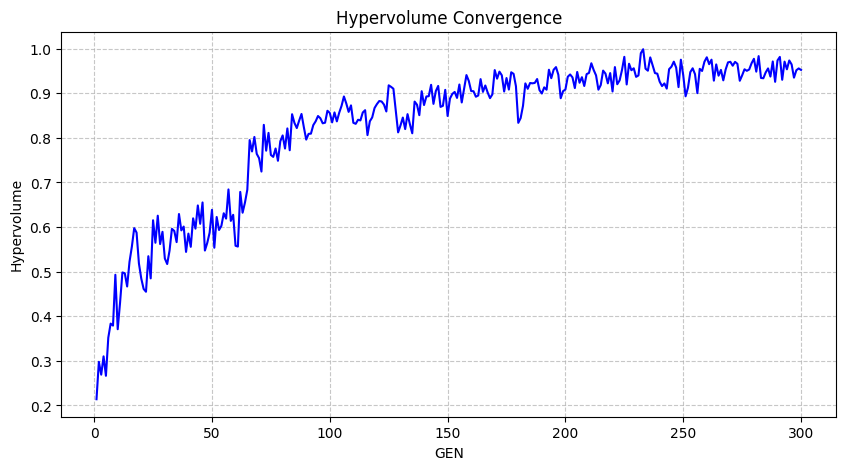

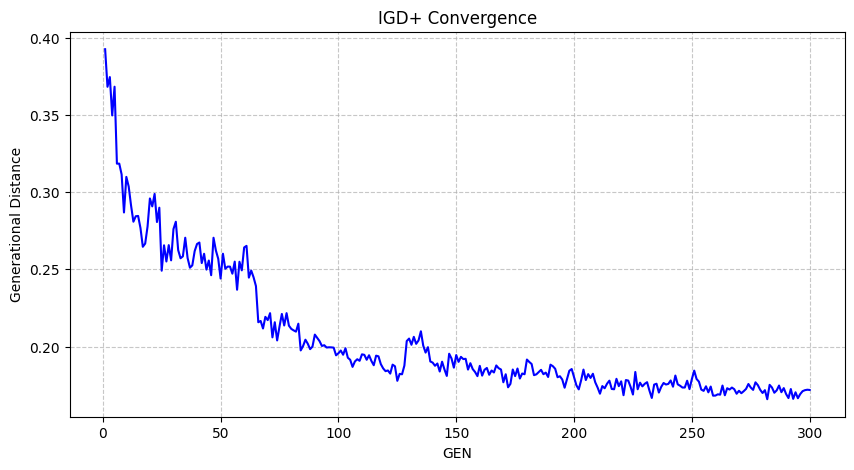

In [2]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
\
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()